In [1]:
!pip install pillow

In [2]:
from PIL import Image
import numpy as np

In [11]:
from google.colab import files
uploaded = files.upload()

Saving stego_surat_aktif_kuliah.png to stego_surat_aktif_kuliah.png


In [4]:
def encode_image(image_path, secret_message):
    img = Image.open(image_path)
    img = img.convert('RGB')
    data = np.array(img)

    binary_message = ''.join(format(ord(i), '08b') for i in secret_message)
    binary_message += '1111111111111110'  # delimiter

    data_flat = data.flatten()

    for i in range(len(binary_message)):
        data_flat[i] = (data_flat[i] & ~1) | int(binary_message[i])

    encoded_data = data_flat.reshape(data.shape)
    encoded_img = Image.fromarray(encoded_data.astype('uint8'), 'RGB')

    encoded_img.save('encoded.png')
    return 'encoded.png'

In [7]:
def encode_image(image_path, secret_message):
    img = Image.open(image_path)
    img = img.convert('RGB')
    data = np.array(img)

    binary_message = ''.join(format(ord(i), '08b') for i in secret_message)
    binary_message += '1111111111111110'  # delimiter

    data_flat = data.flatten()

    for i in range(len(binary_message)):
        # Fix: Replace ~1 with 254 (0xFE) to avoid negative integer overflow
        data_flat[i] = (data_flat[i] & 254) | int(binary_message[i])

    encoded_data = data_flat.reshape(data.shape)
    encoded_img = Image.fromarray(encoded_data.astype('uint8'), 'RGB')

    encoded_img.save('encoded.png')
    return 'encoded.png'

output_image = encode_image('image.png', 'Halo ini pesan rahasia!')
print("Berhasil disisipkan ke:", output_image)

/tmp/ipykernel_23026/495962619.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  encoded_img = Image.fromarray(encoded_data.astype('uint8'), 'RGB')


Berhasil disisipkan ke: encoded.png


In [8]:
files.download('encoded.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
def decode_image(image_path):
    img = Image.open(image_path)
    data = np.array(img)

    data_flat = data.flatten()

    binary_data = ''
    for i in data_flat:
        binary_data += str(i & 1)

    all_bytes = [binary_data[i:i+8] for i in range(0, len(binary_data), 8)]

    decoded_message = ''
    for byte in all_bytes:
        if byte == '11111110':  # delimiter
            break
        decoded_message += chr(int(byte, 2))

    return decoded_message

In [10]:
message = decode_image('encoded.png')
print("Pesan tersembunyi:", message)

Pesan tersembunyi: Halo ini pesan rahasia!ÿ


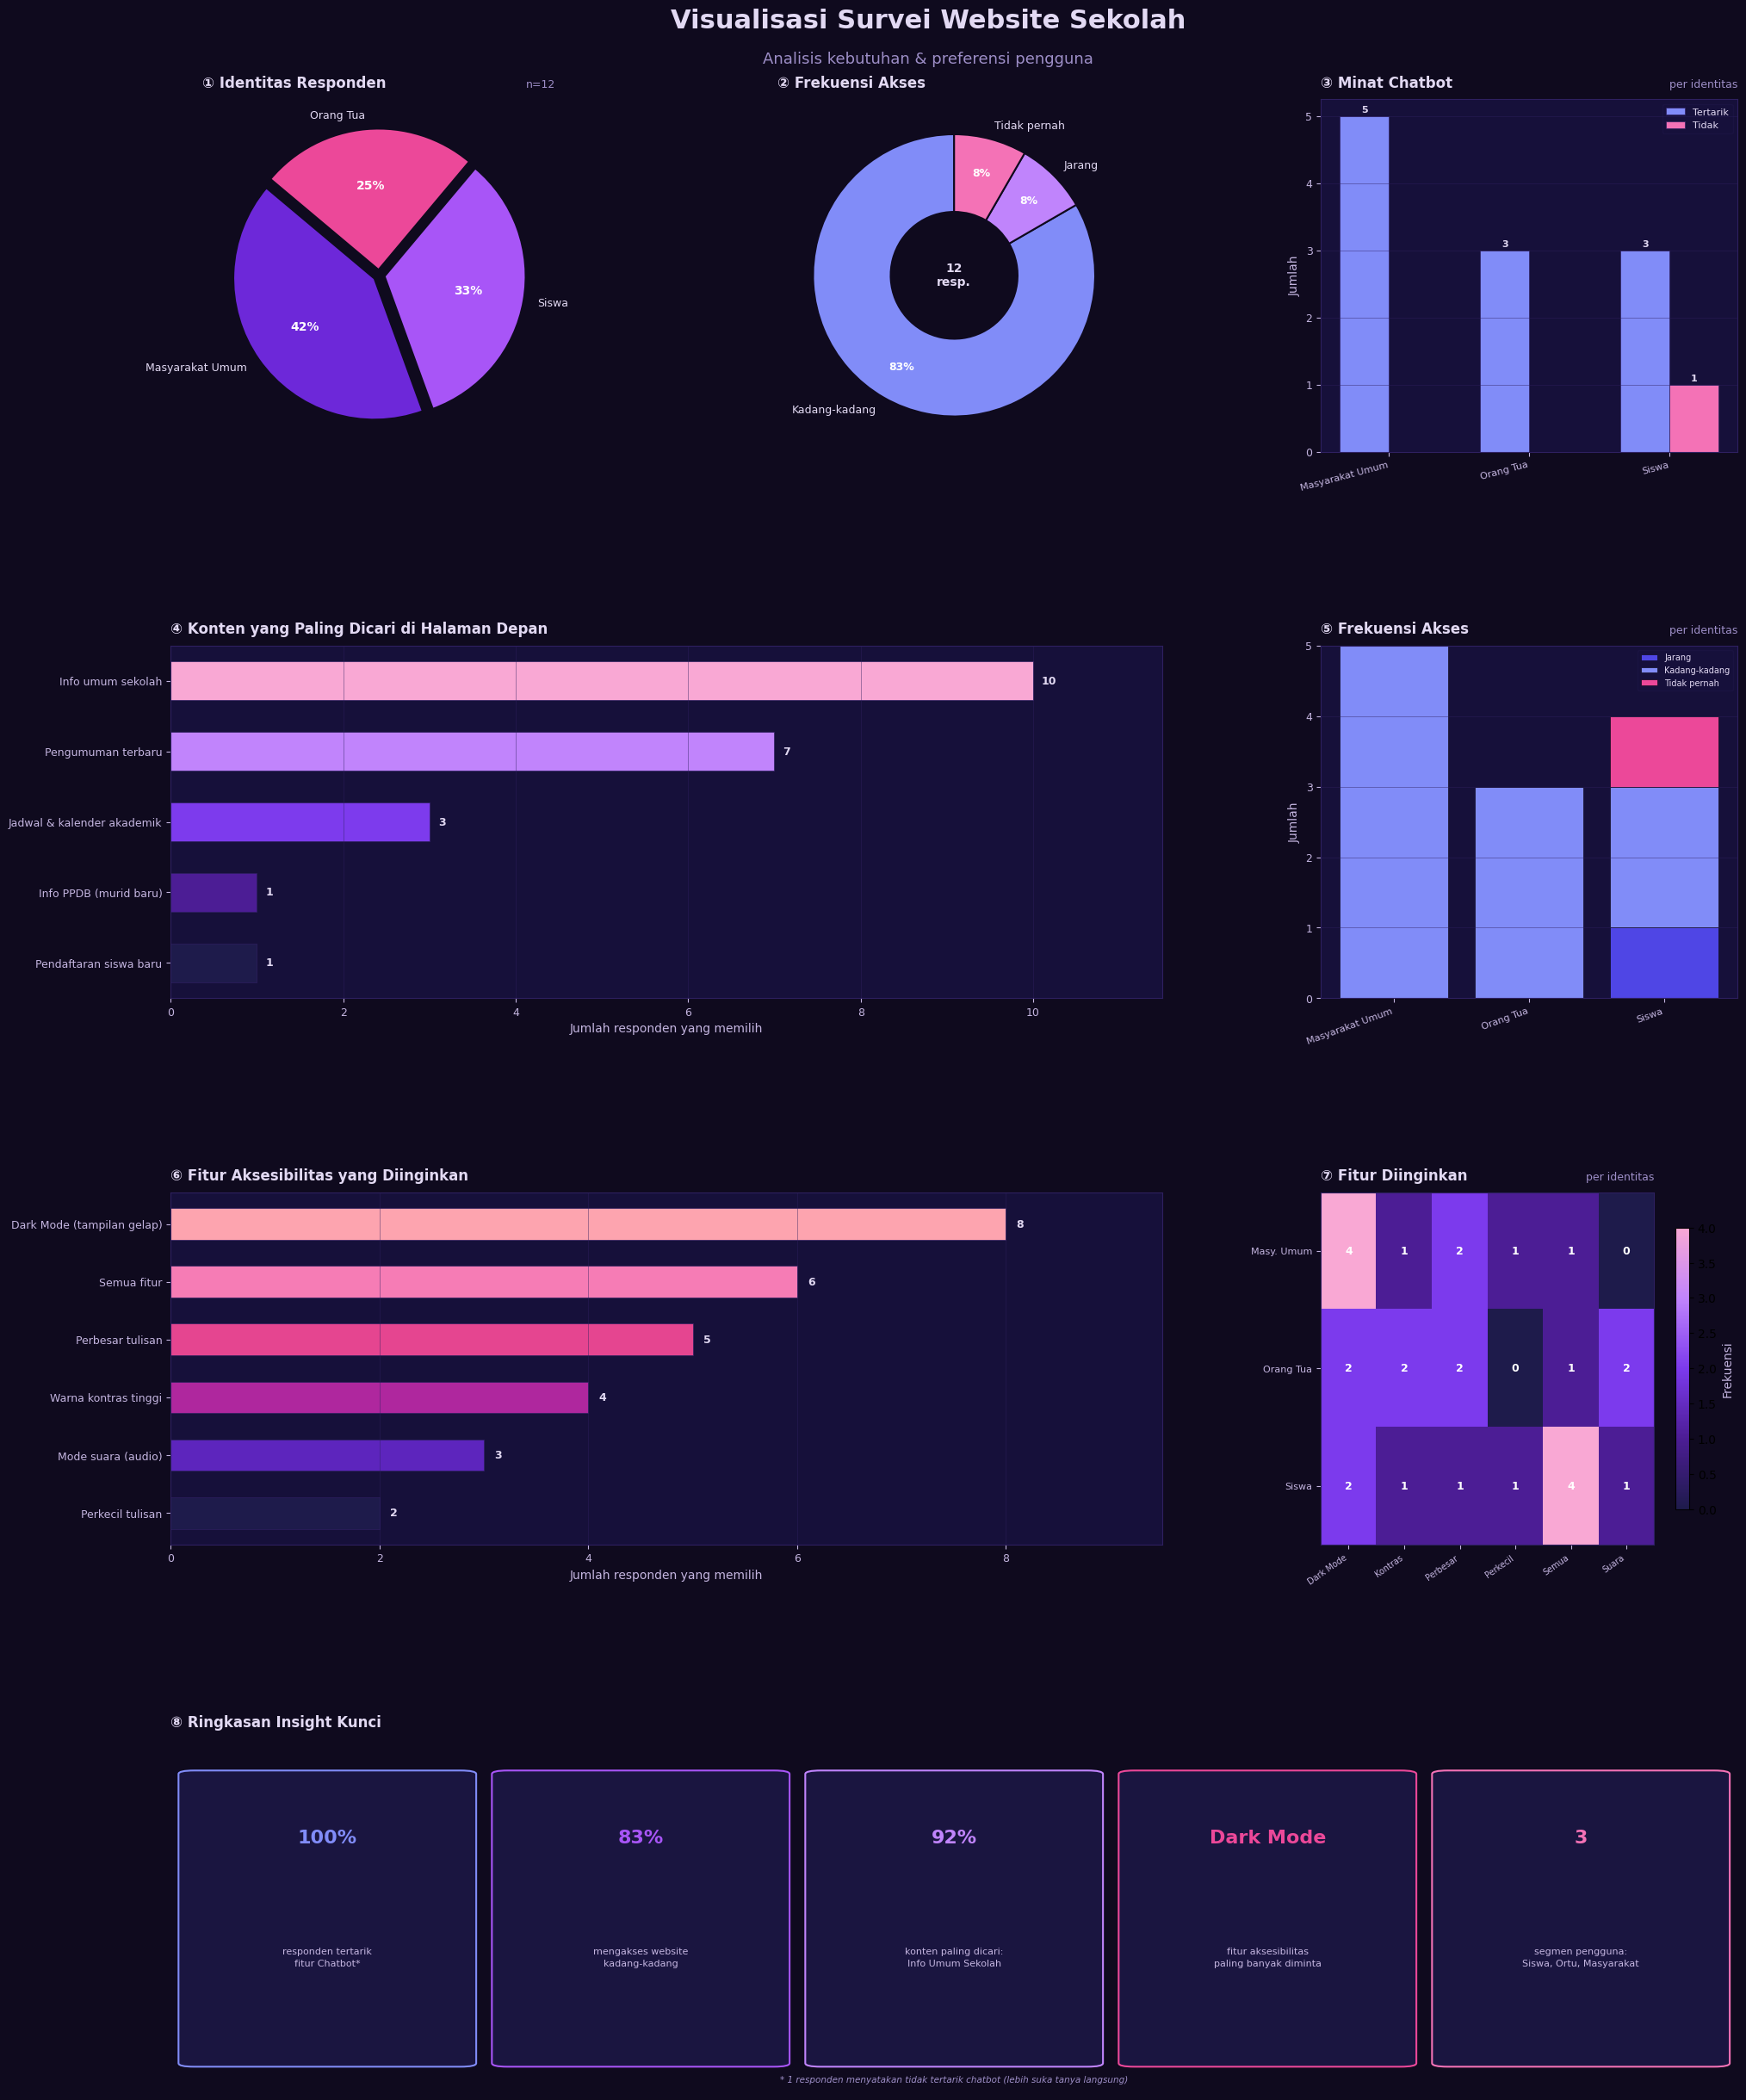


✅ Gambar disimpan: visualisasi_survei_website_sekolah.png


In [12]:
# ============================================================
#  VISUALISASI DATA SURVEI WEBSITE SEKOLAH
#  Jalankan di Google Colab atau Jupyter Notebook
# ============================================================

# Install library yang dibutuhkan (jalankan sekali)
# !pip install matplotlib seaborn pandas numpy

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
#  DATA SURVEI
# ─────────────────────────────────────────────

data_raw = {
    'Identitas': [
        'Siswa', 'orang tua', 'Masyarakat umum',
        'Siswa', 'siswa', 'orang tua',
        'Siswa', 'Masyarakat umum', 'Masyarakat umum',
        'orang tua', 'Masyarakat umum', 'Masyarakat umum'
    ],
    'Frekuensi': [
        'Jarang', 'Kadang-kadang', 'Kadang-kadang',
        'Kadang-kadang', 'Tidak pernah', 'Kadang-kadang',
        'Kadang-kadang', 'Kadang-kadang', 'Kadang-kadang',
        'Kadang-kadang', 'Kadang-kadang', 'Kadang-kadang'
    ],
    'Konten Utama': [
        ['Info umum sekolah', 'Pengumuman terbaru', 'Jadwal & kalender akademik', 'Pendaftaran siswa baru'],
        ['Info umum sekolah', 'Pengumuman terbaru', 'Jadwal & kalender akademik', 'Info PPDB'],
        ['Info umum sekolah'],
        ['Pengumuman terbaru'],
        ['Info umum sekolah'],
        ['Info umum sekolah'],
        ['Info umum sekolah', 'Pengumuman terbaru'],
        ['Info umum sekolah'],
        ['Pengumuman terbaru'],
        ['Info umum sekolah', 'Pengumuman terbaru', 'Jadwal & kalender akademik'],
        ['Info umum sekolah', 'Pengumuman terbaru'],
        ['Info umum sekolah'],
    ],
    'Tertarik Chatbot': [
        'Iya', 'Iya', 'Iya',
        'Iya', 'Tidak', 'Iya',
        'Iya', 'Iya', 'Iya',
        'Iya', 'Iya', 'Iya',
    ],
    'Fitur Diinginkan': [
        ['semua'],
        ['Dark Mode', 'Perbesar tulisan', 'Warna kontras tinggi', 'Mode suara'],
        ['Dark Mode'],
        ['Dark Mode', 'Perbesar tulisan', 'Perkecil tulisan', 'Warna kontras tinggi', 'Mode suara', 'semua'],
        ['Dark Mode', 'semua'],
        ['Dark Mode', 'Perbesar tulisan', 'Warna kontras tinggi', 'Mode suara'],
        ['semua'],
        ['semua'],
        ['Dark Mode', 'Perbesar tulisan', 'Perkecil tulisan', 'Warna kontras tinggi'],
        ['semua'],
        ['Dark Mode'],
        ['Dark Mode', 'Perbesar tulisan'],
    ]
}

df = pd.DataFrame(data_raw)

# ─────────────────────────────────────────────
#  PALETTE WARNA GRADASI ELEGAN
# ─────────────────────────────────────────────

# Gradasi utama: Deep Navy → Violet → Rose Gold
elegant_colors = ['#1a1a2e', '#16213e', '#533483', '#8b5cf6', '#c084fc', '#f472b6', '#fb7185']

# Palette per kategori
palette_identitas = {
    'Siswa':           '#6d28d9',
    'orang tua':       '#7c3aed',
    'Masyarakat umum': '#a855f7',
}
palette_frek = {
    'Kadang-kadang': '#818cf8',
    'Jarang':        '#c084fc',
    'Tidak pernah':  '#f472b6',
}

# Custom colormap elegan
cmap_elegant = LinearSegmentedColormap.from_list(
    'elegant', ['#1e1b4b', '#4c1d95', '#7c3aed', '#c084fc', '#f9a8d4'], N=256
)
cmap_rose = LinearSegmentedColormap.from_list(
    'rose', ['#1e1b4b', '#6d28d9', '#db2777', '#f472b6', '#fda4af'], N=256
)

# ─────────────────────────────────────────────
#  SETUP FIGURE UTAMA
# ─────────────────────────────────────────────

fig = plt.figure(figsize=(20, 26), facecolor='#0f0a1e')
fig.patch.set_facecolor('#0f0a1e')

gs = gridspec.GridSpec(
    4, 3,
    figure=fig,
    hspace=0.55,
    wspace=0.38,
    top=0.93, bottom=0.04,
    left=0.06, right=0.97
)

# Judul utama
fig.text(
    0.5, 0.965,
    'Visualisasi Survei Website Sekolah',
    ha='center', va='center',
    fontsize=22, fontweight='bold',
    color='#e2d9f3',
    fontfamily='DejaVu Sans'
)
fig.text(
    0.5, 0.948,
    'Analisis kebutuhan & preferensi pengguna',
    ha='center', va='center',
    fontsize=13, color='#9d8ec7'
)

# ─────────────────────────────────────────────
#  HELPER: style axes
# ─────────────────────────────────────────────
def style_ax(ax, title, subtitle=''):
    ax.set_facecolor('#16103a')
    for spine in ax.spines.values():
        spine.set_edgecolor('#2e2060')
        spine.set_linewidth(0.8)
    ax.tick_params(colors='#c4b5e0', labelsize=9)
    ax.set_title(title, color='#e2d9f3', fontsize=12,
                 fontweight='bold', pad=10, loc='left')
    if subtitle:
        ax.set_title(subtitle, color='#9d8ec7', fontsize=9, pad=10, loc='right')
    ax.xaxis.label.set_color('#c4b5e0')
    ax.yaxis.label.set_color('#c4b5e0')

def bar_grad(ax, categories, values, cmap_name='elegant', horizontal=False):
    """Buat bar dengan warna gradasi."""
    cm = cmap_elegant if cmap_name == 'elegant' else cmap_rose
    n = len(values)
    colors = [cm(i / max(n - 1, 1)) for i in range(n)]
    if horizontal:
        bars = ax.barh(categories, values, color=colors,
                       edgecolor='#2e2060', linewidth=0.5, height=0.6)
        for bar, val in zip(bars, values):
            ax.text(val + 0.05, bar.get_y() + bar.get_height() / 2,
                    str(val), va='center', color='#e2d9f3', fontsize=9, fontweight='bold')
    else:
        bars = ax.bar(categories, values, color=colors,
                      edgecolor='#2e2060', linewidth=0.5, width=0.6)
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                    str(val), ha='center', color='#e2d9f3', fontsize=9, fontweight='bold')
    return bars

# ─────────────────────────────────────────────
#  CHART 1: Distribusi Identitas Responden (Pie)
# ─────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor('#16103a')
style_ax(ax1, '① Identitas Responden', f'n={len(df)}')

id_counts = df['Identitas'].str.lower().str.strip()
id_counts = id_counts.map({'siswa': 'Siswa', 'orang tua': 'Orang Tua', 'masyarakat umum': 'Masyarakat Umum'})
id_counts = id_counts.value_counts()

wedge_colors = ['#6d28d9', '#a855f7', '#ec4899']
explode = [0.04] * len(id_counts)
wedges, texts, autotexts = ax1.pie(
    id_counts.values,
    labels=id_counts.index,
    autopct='%1.0f%%',
    colors=wedge_colors,
    explode=explode,
    startangle=140,
    textprops={'color': '#e2d9f3', 'fontsize': 9},
    wedgeprops={'edgecolor': '#0f0a1e', 'linewidth': 1.5}
)
for at in autotexts:
    at.set_color('#ffffff')
    at.set_fontweight('bold')
    at.set_fontsize(10)
ax1.set_aspect('equal')

# ─────────────────────────────────────────────
#  CHART 2: Frekuensi Akses Website (Donut)
# ─────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor('#16103a')
style_ax(ax2, '② Frekuensi Akses')

frek_counts = df['Frekuensi'].value_counts()
frek_colors = ['#818cf8', '#c084fc', '#f472b6']
wedges2, texts2, autotexts2 = ax2.pie(
    frek_counts.values,
    labels=frek_counts.index,
    autopct='%1.0f%%',
    colors=frek_colors,
    startangle=90,
    pctdistance=0.75,
    wedgeprops={'width': 0.55, 'edgecolor': '#0f0a1e', 'linewidth': 1.5},
    textprops={'color': '#e2d9f3', 'fontsize': 9}
)
for at in autotexts2:
    at.set_color('#ffffff')
    at.set_fontweight('bold')
# Label total di tengah donut
ax2.text(0, 0, f'{len(df)}\nresp.', ha='center', va='center',
         color='#e2d9f3', fontsize=10, fontweight='bold')
ax2.set_aspect('equal')

# ─────────────────────────────────────────────
#  CHART 3: Chatbot Interest (Bar grouped)
# ─────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
style_ax(ax3, '③ Minat Chatbot', 'per identitas')

chatbot_cross = pd.crosstab(
    df['Identitas'].str.strip().str.lower()
       .map({'siswa': 'Siswa', 'orang tua': 'Orang Tua', 'masyarakat umum': 'Masyarakat Umum'}),
    df['Tertarik Chatbot']
)
x = np.arange(len(chatbot_cross.index))
w = 0.35
colors_yes = '#818cf8'
colors_no  = '#f472b6'

b1 = ax3.bar(x - w/2,
             chatbot_cross.get('Iya', pd.Series(0, index=chatbot_cross.index)),
             w, label='Tertarik', color=colors_yes, edgecolor='#2e2060', linewidth=0.5)
b2 = ax3.bar(x + w/2,
             chatbot_cross.get('Tidak', pd.Series(0, index=chatbot_cross.index)),
             w, label='Tidak', color=colors_no, edgecolor='#2e2060', linewidth=0.5)

ax3.set_xticks(x)
ax3.set_xticklabels(chatbot_cross.index, rotation=15, ha='right', color='#c4b5e0', fontsize=8)
ax3.set_ylabel('Jumlah', color='#c4b5e0')
ax3.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax3.legend(framealpha=0.2, labelcolor='#e2d9f3',
           facecolor='#1a1540', edgecolor='#2e2060', fontsize=8)
ax3.grid(axis='y', color='#2e2060', linewidth=0.5, alpha=0.6)

for bar in list(b1) + list(b2):
    h = bar.get_height()
    if h > 0:
        ax3.text(bar.get_x() + bar.get_width()/2, h + 0.05, str(int(h)),
                 ha='center', color='#e2d9f3', fontsize=8, fontweight='bold')

# ─────────────────────────────────────────────
#  CHART 4: Konten Paling Dicari (Horizontal Bar)
# ─────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, :2])
style_ax(ax4, '④ Konten yang Paling Dicari di Halaman Depan')

konten_flat = []
for items in df['Konten Utama']:
    konten_flat.extend(items)
konten_series = pd.Series(konten_flat)
konten_counts = konten_series.value_counts().sort_values()

label_map = {
    'Info umum sekolah': 'Info umum sekolah',
    'Pengumuman terbaru': 'Pengumuman terbaru',
    'Jadwal & kalender akademik': 'Jadwal & kalender akademik',
    'Pendaftaran siswa baru': 'Pendaftaran siswa baru',
    'Info PPDB': 'Info PPDB (murid baru)',
}
konten_counts.index = [label_map.get(i, i) for i in konten_counts.index]

n = len(konten_counts)
bar_colors = [cmap_elegant(i / max(n - 1, 1)) for i in range(n)]
bars4 = ax4.barh(konten_counts.index, konten_counts.values,
                 color=bar_colors, edgecolor='#2e2060', linewidth=0.5, height=0.55)
for bar, val in zip(bars4, konten_counts.values):
    ax4.text(val + 0.1, bar.get_y() + bar.get_height()/2, str(val),
             va='center', color='#e2d9f3', fontsize=9, fontweight='bold')
ax4.set_xlabel('Jumlah responden yang memilih', color='#c4b5e0')
ax4.grid(axis='x', color='#2e2060', linewidth=0.5, alpha=0.6)
ax4.set_xlim(0, konten_counts.max() + 1.5)

# ─────────────────────────────────────────────
#  CHART 5: Frekuensi per Identitas (Stacked Bar)
# ─────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
style_ax(ax5, '⑤ Frekuensi Akses', 'per identitas')

id_clean = df['Identitas'].str.strip().str.lower().map(
    {'siswa': 'Siswa', 'orang tua': 'Orang Tua', 'masyarakat umum': 'Masyarakat Umum'}
)
frek_id = pd.crosstab(id_clean, df['Frekuensi'])
frek_colors_stack = ['#4f46e5', '#818cf8', '#ec4899']

bottom = np.zeros(len(frek_id))
for i, col in enumerate(frek_id.columns):
    vals = frek_id[col].values
    color = frek_colors_stack[i % len(frek_colors_stack)]
    ax5.bar(frek_id.index, vals, bottom=bottom,
            label=col, color=color, edgecolor='#0f0a1e', linewidth=0.5)
    bottom += vals

ax5.set_xticklabels(frek_id.index, rotation=20, ha='right', fontsize=8, color='#c4b5e0')
ax5.set_ylabel('Jumlah', color='#c4b5e0')
ax5.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax5.legend(framealpha=0.2, labelcolor='#e2d9f3',
           facecolor='#1a1540', edgecolor='#2e2060', fontsize=7, loc='upper right')
ax5.grid(axis='y', color='#2e2060', linewidth=0.5, alpha=0.6)

# ─────────────────────────────────────────────
#  CHART 6: Fitur Aksesibilitas yang Diinginkan (Bar)
# ─────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, :2])
style_ax(ax6, '⑥ Fitur Aksesibilitas yang Diinginkan')

fitur_flat = []
for items in df['Fitur Diinginkan']:
    fitur_flat.extend(items)
fitur_series = pd.Series(fitur_flat)
fitur_counts = fitur_series.value_counts().sort_values()

fitur_label = {
    'Dark Mode': 'Dark Mode (tampilan gelap)',
    'Perbesar tulisan': 'Perbesar tulisan',
    'Perkecil tulisan': 'Perkecil tulisan',
    'Warna kontras tinggi': 'Warna kontras tinggi',
    'Mode suara': 'Mode suara (audio)',
    'semua': 'Semua fitur',
}
fitur_counts.index = [fitur_label.get(i, i) for i in fitur_counts.index]

n6 = len(fitur_counts)
bar_colors6 = [cmap_rose(i / max(n6 - 1, 1)) for i in range(n6)]
bars6 = ax6.barh(fitur_counts.index, fitur_counts.values,
                 color=bar_colors6, edgecolor='#2e2060', linewidth=0.5, height=0.55)
for bar, val in zip(bars6, fitur_counts.values):
    ax6.text(val + 0.1, bar.get_y() + bar.get_height()/2, str(val),
             va='center', color='#e2d9f3', fontsize=9, fontweight='bold')
ax6.set_xlabel('Jumlah responden yang memilih', color='#c4b5e0')
ax6.grid(axis='x', color='#2e2060', linewidth=0.5, alpha=0.6)
ax6.set_xlim(0, fitur_counts.max() + 1.5)

# ─────────────────────────────────────────────
#  CHART 7: Heatmap Fitur per Identitas
# ─────────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 2])
style_ax(ax7, '⑦ Fitur Diinginkan', 'per identitas')

id_label_clean = df['Identitas'].str.strip().str.lower().map(
    {'siswa': 'Siswa', 'orang tua': 'Orang Tua', 'masyarakat umum': 'Masy. Umum'}
)
fitur_label_short = {
    'Dark Mode': 'Dark Mode',
    'Perbesar tulisan': 'Perbesar',
    'Perkecil tulisan': 'Perkecil',
    'Warna kontras tinggi': 'Kontras',
    'Mode suara': 'Suara',
    'semua': 'Semua',
}
rows = []
for idx, row in df.iterrows():
    id_ = id_label_clean[idx]
    for f in row['Fitur Diinginkan']:
        rows.append({'Identitas': id_, 'Fitur': fitur_label_short.get(f, f)})

df_fitur = pd.DataFrame(rows)
heatmap_data = pd.crosstab(df_fitur['Identitas'], df_fitur['Fitur'])

im = ax7.imshow(heatmap_data.values, aspect='auto', cmap=cmap_elegant)
ax7.set_xticks(range(len(heatmap_data.columns)))
ax7.set_yticks(range(len(heatmap_data.index)))
ax7.set_xticklabels(heatmap_data.columns, rotation=35, ha='right', fontsize=7, color='#c4b5e0')
ax7.set_yticklabels(heatmap_data.index, fontsize=8, color='#c4b5e0')
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        val = heatmap_data.values[i, j]
        ax7.text(j, i, str(val), ha='center', va='center',
                 color='white', fontsize=9, fontweight='bold')
plt.colorbar(im, ax=ax7, shrink=0.8,
             label='Frekuensi').ax.yaxis.label.set_color('#c4b5e0')

# ─────────────────────────────────────────────
#  CHART 8: Ringkasan Insight Kunci (teks visual)
# ─────────────────────────────────────────────
ax8 = fig.add_subplot(gs[3, :])
ax8.set_facecolor('#12103a')
ax8.set_xlim(0, 1)
ax8.set_ylim(0, 1)
ax8.axis('off')
style_ax(ax8, '⑧ Ringkasan Insight Kunci')

insights = [
    ('100%', 'responden tertarik\nfitur Chatbot*', '#818cf8'),
    (f'{round(df["Frekuensi"].value_counts(normalize=True)["Kadang-kadang"]*100)}%',
     'mengakses website\nkadang-kadang', '#a855f7'),
    ('92%', 'konten paling dicari:\nInfo Umum Sekolah', '#c084fc'),
    ('Dark Mode', 'fitur aksesibilitas\npaling banyak diminta', '#ec4899'),
    ('3', 'segmen pengguna:\nSiswa, Ortu, Masyarakat', '#f472b6'),
]

n_ins = len(insights)
for i, (val, label, color) in enumerate(insights):
    x_pos = (i + 0.5) / n_ins
    rect = mpatches.FancyBboxPatch(
        (x_pos - 0.085, 0.08), 0.17, 0.82,
        boxstyle='round,pad=0.01',
        facecolor='#1a1540', edgecolor=color, linewidth=1.5,
        transform=ax8.transAxes
    )
    ax8.add_patch(rect)
    ax8.text(x_pos, 0.72, val, ha='center', va='center',
             transform=ax8.transAxes,
             fontsize=16, fontweight='bold', color=color)
    ax8.text(x_pos, 0.38, label, ha='center', va='center',
             transform=ax8.transAxes,
             fontsize=8, color='#c4b5e0', linespacing=1.5)

ax8.text(0.5, 0.02, '* 1 responden menyatakan tidak tertarik chatbot (lebih suka tanya langsung)',
         ha='center', va='bottom', transform=ax8.transAxes,
         fontsize=7.5, color='#9d8ec7', style='italic')

# ─────────────────────────────────────────────
#  SIMPAN & TAMPILKAN
# ─────────────────────────────────────────────
plt.savefig('visualisasi_survei_website_sekolah.png',
            dpi=180, bbox_inches='tight',
            facecolor='#0f0a1e', edgecolor='none')
plt.show()
print("\n✅ Gambar disimpan: visualisasi_survei_website_sekolah.png")

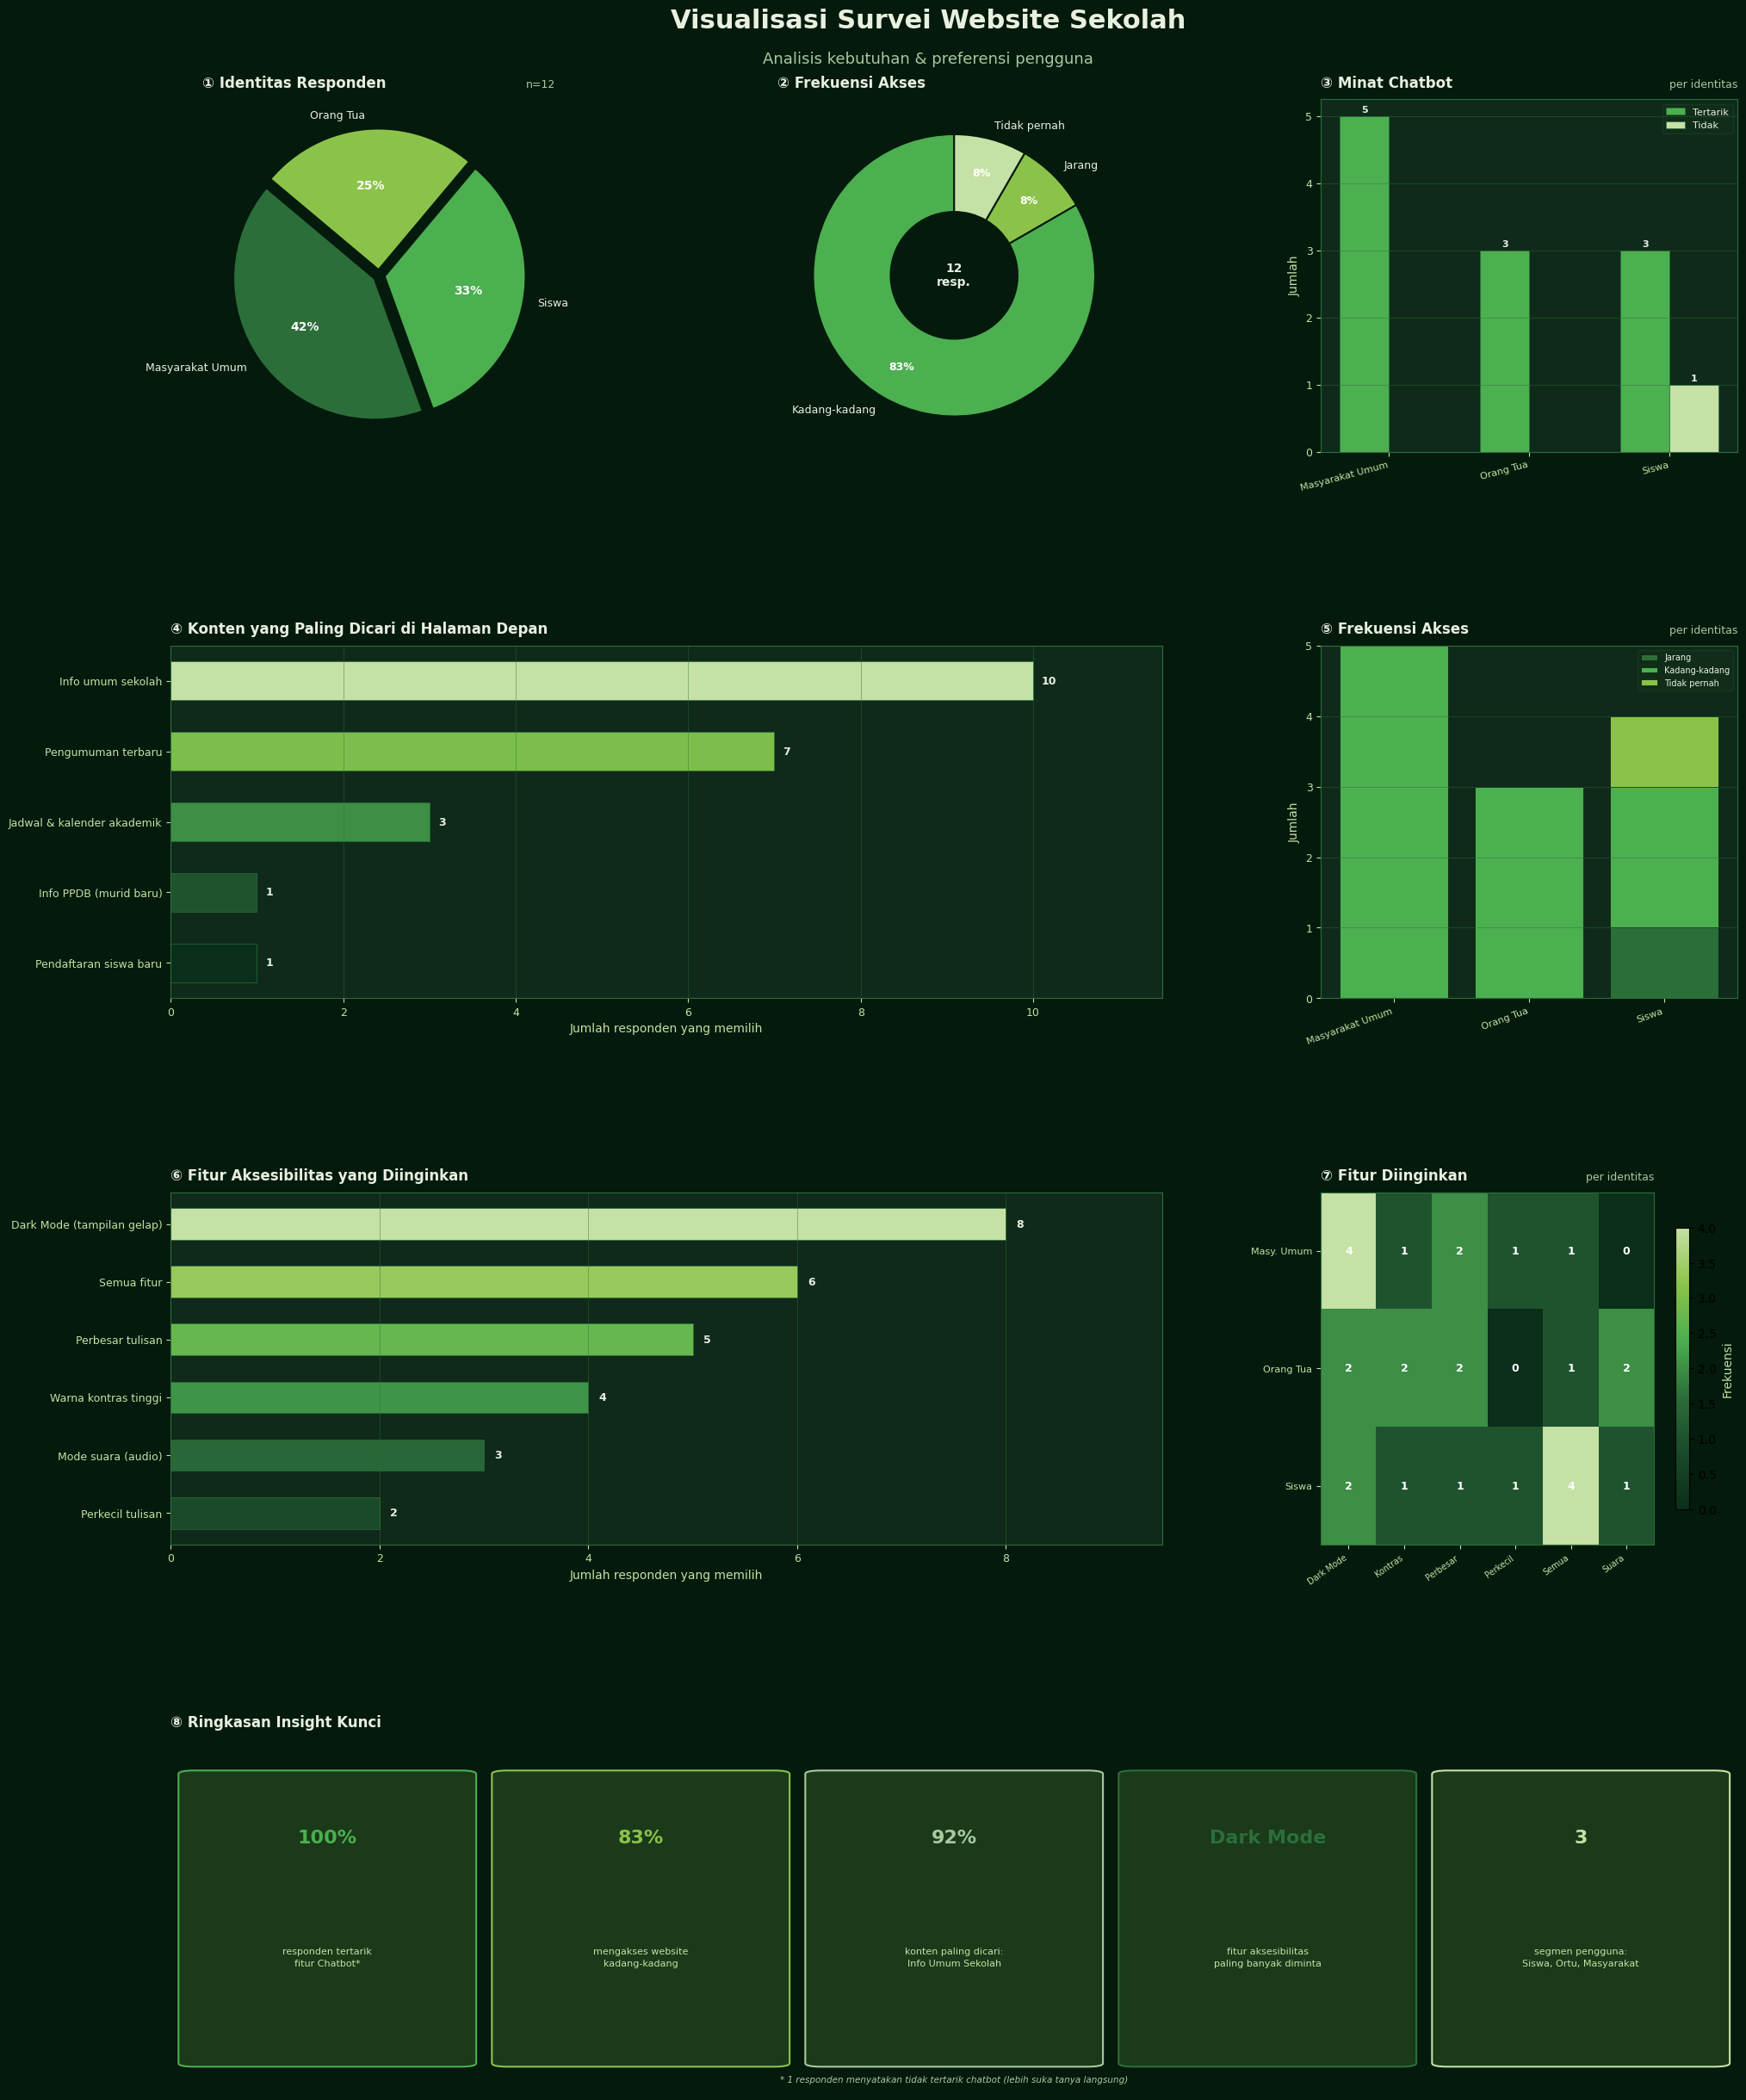


✅ Gambar disimpan: visualisasi_survei_website_sekolah.png


In [13]:
# ============================================================
#  VISUALISASI DATA SURVEI WEBSITE SEKOLAH
#  Jalankan di Google Colab atau Jupyter Notebook
# ============================================================

# Install library yang dibutuhkan (jalankan sekali)
# !pip install matplotlib seaborn pandas numpy

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
#  DATA SURVEI
# ─────────────────────────────────────────────

data_raw = {
    'Identitas': [
        'Siswa', 'orang tua', 'Masyarakat umum',
        'Siswa', 'siswa', 'orang tua',
        'Siswa', 'Masyarakat umum', 'Masyarakat umum',
        'orang tua', 'Masyarakat umum', 'Masyarakat umum'
    ],
    'Frekuensi': [
        'Jarang', 'Kadang-kadang', 'Kadang-kadang',
        'Kadang-kadang', 'Tidak pernah', 'Kadang-kadang',
        'Kadang-kadang', 'Kadang-kadang', 'Kadang-kadang',
        'Kadang-kadang', 'Kadang-kadang', 'Kadang-kadang'
    ],
    'Konten Utama': [
        ['Info umum sekolah', 'Pengumuman terbaru', 'Jadwal & kalender akademik', 'Pendaftaran siswa baru'],
        ['Info umum sekolah', 'Pengumuman terbaru', 'Jadwal & kalender akademik', 'Info PPDB'],
        ['Info umum sekolah'],
        ['Pengumuman terbaru'],
        ['Info umum sekolah'],
        ['Info umum sekolah'],
        ['Info umum sekolah', 'Pengumuman terbaru'],
        ['Info umum sekolah'],
        ['Pengumuman terbaru'],
        ['Info umum sekolah', 'Pengumuman terbaru', 'Jadwal & kalender akademik'],
        ['Info umum sekolah', 'Pengumuman terbaru'],
        ['Info umum sekolah'],
    ],
    'Tertarik Chatbot': [
        'Iya', 'Iya', 'Iya',
        'Iya', 'Tidak', 'Iya',
        'Iya', 'Iya', 'Iya',
        'Iya', 'Iya', 'Iya',
    ],
    'Fitur Diinginkan': [
        ['semua'],
        ['Dark Mode', 'Perbesar tulisan', 'Warna kontras tinggi', 'Mode suara'],
        ['Dark Mode'],
        ['Dark Mode', 'Perbesar tulisan', 'Perkecil tulisan', 'Warna kontras tinggi', 'Mode suara', 'semua'],
        ['Dark Mode', 'semua'],
        ['Dark Mode', 'Perbesar tulisan', 'Warna kontras tinggi', 'Mode suara'],
        ['semua'],
        ['semua'],
        ['Dark Mode', 'Perbesar tulisan', 'Perkecil tulisan', 'Warna kontras tinggi'],
        ['semua'],
        ['Dark Mode'],
        ['Dark Mode', 'Perbesar tulisan'],
    ]
}

df = pd.DataFrame(data_raw)

# ─────────────────────────────────────────────
#  PALETTE WARNA GRADASI MUHAMMADIYAH MODERN (GREEN)
# ─────────────────────────────────────────────

# Gradasi utama: Deep Forest Green → Emerald → Mint
muhammadiyah_green = ['#0A2F1A', '#1A4A2A', '#2C6E3A', '#4CAF50', '#8BC34A', '#C5E1A5', '#E8F0E0']

# Palette per kategori - nuansa hijau
palette_identitas = {
    'Siswa':           '#2C6E3A',
    'orang tua':       '#4CAF50',
    'Masyarakat umum': '#8BC34A',
}
palette_frek = {
    'Kadang-kadang': '#4CAF50',
    'Jarang':        '#8BC34A',
    'Tidak pernah':  '#C5E1A5',
}

# Custom colormap gradasi hijau
cmap_elegant = LinearSegmentedColormap.from_list(
    'muhammadiyah_green', ['#0A2F1A', '#1A4A2A', '#2C6E3A', '#4CAF50', '#8BC34A', '#C5E1A5'], N=256
)
cmap_rose = LinearSegmentedColormap.from_list(
    'muhammadiyah_light', ['#1A4A2A', '#2C6E3A', '#4CAF50', '#8BC34A', '#C5E1A5'], N=256
)

# ─────────────────────────────────────────────
#  SETUP FIGURE UTAMA
# ─────────────────────────────────────────────

fig = plt.figure(figsize=(20, 26), facecolor='#041A0C')  # dark green background
fig.patch.set_facecolor('#041A0C')

gs = gridspec.GridSpec(
    4, 3,
    figure=fig,
    hspace=0.55,
    wspace=0.38,
    top=0.93, bottom=0.04,
    left=0.06, right=0.97
)

# Judul utama
fig.text(
    0.5, 0.965,
    'Visualisasi Survei Website Sekolah',
    ha='center', va='center',
    fontsize=22, fontweight='bold',
    color='#E8F0E0',
    fontfamily='DejaVu Sans'
)
fig.text(
    0.5, 0.948,
    'Analisis kebutuhan & preferensi pengguna',
    ha='center', va='center',
    fontsize=13, color='#A8C9A0'
)

# ─────────────────────────────────────────────
#  HELPER: style axes
# ─────────────────────────────────────────────
def style_ax(ax, title, subtitle=''):
    ax.set_facecolor('#0F2A1A')
    for spine in ax.spines.values():
        spine.set_edgecolor('#2C6E3A')
        spine.set_linewidth(0.8)
    ax.tick_params(colors='#C5E1A5', labelsize=9)
    ax.set_title(title, color='#E8F0E0', fontsize=12,
                 fontweight='bold', pad=10, loc='left')
    if subtitle:
        ax.set_title(subtitle, color='#A8C9A0', fontsize=9, pad=10, loc='right')
    ax.xaxis.label.set_color('#C5E1A5')
    ax.yaxis.label.set_color('#C5E1A5')

def bar_grad(ax, categories, values, cmap_name='elegant', horizontal=False):
    """Buat bar dengan warna gradasi (versi hijau)."""
    cm = cmap_elegant if cmap_name == 'elegant' else cmap_rose
    n = len(values)
    colors = [cm(i / max(n - 1, 1)) for i in range(n)]
    if horizontal:
        bars = ax.barh(categories, values, color=colors,
                       edgecolor='#2C6E3A', linewidth=0.5, height=0.6)
        for bar, val in zip(bars, values):
            ax.text(val + 0.05, bar.get_y() + bar.get_height() / 2,
                    str(val), va='center', color='#E8F0E0', fontsize=9, fontweight='bold')
    else:
        bars = ax.bar(categories, values, color=colors,
                      edgecolor='#2C6E3A', linewidth=0.5, width=0.6)
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                    str(val), ha='center', color='#E8F0E0', fontsize=9, fontweight='bold')
    return bars

# ─────────────────────────────────────────────
#  CHART 1: Distribusi Identitas Responden (Pie)
# ─────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor('#0F2A1A')
style_ax(ax1, '① Identitas Responden', f'n={len(df)}')

id_counts = df['Identitas'].str.lower().str.strip()
id_counts = id_counts.map({'siswa': 'Siswa', 'orang tua': 'Orang Tua', 'masyarakat umum': 'Masyarakat Umum'})
id_counts = id_counts.value_counts()

wedge_colors = ['#2C6E3A', '#4CAF50', '#8BC34A']
explode = [0.04] * len(id_counts)
wedges, texts, autotexts = ax1.pie(
    id_counts.values,
    labels=id_counts.index,
    autopct='%1.0f%%',
    colors=wedge_colors,
    explode=explode,
    startangle=140,
    textprops={'color': '#E8F0E0', 'fontsize': 9},
    wedgeprops={'edgecolor': '#041A0C', 'linewidth': 1.5}
)
for at in autotexts:
    at.set_color('#ffffff')
    at.set_fontweight('bold')
    at.set_fontsize(10)
ax1.set_aspect('equal')

# ─────────────────────────────────────────────
#  CHART 2: Frekuensi Akses Website (Donut)
# ─────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor('#0F2A1A')
style_ax(ax2, '② Frekuensi Akses')

frek_counts = df['Frekuensi'].value_counts()
frek_colors = ['#4CAF50', '#8BC34A', '#C5E1A5']
wedges2, texts2, autotexts2 = ax2.pie(
    frek_counts.values,
    labels=frek_counts.index,
    autopct='%1.0f%%',
    colors=frek_colors,
    startangle=90,
    pctdistance=0.75,
    wedgeprops={'width': 0.55, 'edgecolor': '#041A0C', 'linewidth': 1.5},
    textprops={'color': '#E8F0E0', 'fontsize': 9}
)
for at in autotexts2:
    at.set_color('#ffffff')
    at.set_fontweight('bold')
ax2.text(0, 0, f'{len(df)}\nresp.', ha='center', va='center',
         color='#E8F0E0', fontsize=10, fontweight='bold')
ax2.set_aspect('equal')

# ─────────────────────────────────────────────
#  CHART 3: Chatbot Interest (Bar grouped)
# ─────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
style_ax(ax3, '③ Minat Chatbot', 'per identitas')

chatbot_cross = pd.crosstab(
    df['Identitas'].str.strip().str.lower()
       .map({'siswa': 'Siswa', 'orang tua': 'Orang Tua', 'masyarakat umum': 'Masyarakat Umum'}),
    df['Tertarik Chatbot']
)
x = np.arange(len(chatbot_cross.index))
w = 0.35
colors_yes = '#4CAF50'
colors_no  = '#C5E1A5'

b1 = ax3.bar(x - w/2,
             chatbot_cross.get('Iya', pd.Series(0, index=chatbot_cross.index)),
             w, label='Tertarik', color=colors_yes, edgecolor='#2C6E3A', linewidth=0.5)
b2 = ax3.bar(x + w/2,
             chatbot_cross.get('Tidak', pd.Series(0, index=chatbot_cross.index)),
             w, label='Tidak', color=colors_no, edgecolor='#2C6E3A', linewidth=0.5)

ax3.set_xticks(x)
ax3.set_xticklabels(chatbot_cross.index, rotation=15, ha='right', color='#C5E1A5', fontsize=8)
ax3.set_ylabel('Jumlah', color='#C5E1A5')
ax3.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax3.legend(framealpha=0.2, labelcolor='#E8F0E0',
           facecolor='#1A3A1A', edgecolor='#2C6E3A', fontsize=8)
ax3.grid(axis='y', color='#2C6E3A', linewidth=0.5, alpha=0.6)

for bar in list(b1) + list(b2):
    h = bar.get_height()
    if h > 0:
        ax3.text(bar.get_x() + bar.get_width()/2, h + 0.05, str(int(h)),
                 ha='center', color='#E8F0E0', fontsize=8, fontweight='bold')

# ─────────────────────────────────────────────
#  CHART 4: Konten Paling Dicari (Horizontal Bar)
# ─────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, :2])
style_ax(ax4, '④ Konten yang Paling Dicari di Halaman Depan')

konten_flat = []
for items in df['Konten Utama']:
    konten_flat.extend(items)
konten_series = pd.Series(konten_flat)
konten_counts = konten_series.value_counts().sort_values()

label_map = {
    'Info umum sekolah': 'Info umum sekolah',
    'Pengumuman terbaru': 'Pengumuman terbaru',
    'Jadwal & kalender akademik': 'Jadwal & kalender akademik',
    'Pendaftaran siswa baru': 'Pendaftaran siswa baru',
    'Info PPDB': 'Info PPDB (murid baru)',
}
konten_counts.index = [label_map.get(i, i) for i in konten_counts.index]

n = len(konten_counts)
bar_colors = [cmap_elegant(i / max(n - 1, 1)) for i in range(n)]
bars4 = ax4.barh(konten_counts.index, konten_counts.values,
                 color=bar_colors, edgecolor='#2C6E3A', linewidth=0.5, height=0.55)
for bar, val in zip(bars4, konten_counts.values):
    ax4.text(val + 0.1, bar.get_y() + bar.get_height()/2, str(val),
             va='center', color='#E8F0E0', fontsize=9, fontweight='bold')
ax4.set_xlabel('Jumlah responden yang memilih', color='#C5E1A5')
ax4.grid(axis='x', color='#2C6E3A', linewidth=0.5, alpha=0.6)
ax4.set_xlim(0, konten_counts.max() + 1.5)

# ─────────────────────────────────────────────
#  CHART 5: Frekuensi per Identitas (Stacked Bar)
# ─────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
style_ax(ax5, '⑤ Frekuensi Akses', 'per identitas')

id_clean = df['Identitas'].str.strip().str.lower().map(
    {'siswa': 'Siswa', 'orang tua': 'Orang Tua', 'masyarakat umum': 'Masyarakat Umum'}
)
frek_id = pd.crosstab(id_clean, df['Frekuensi'])
frek_colors_stack = ['#2C6E3A', '#4CAF50', '#8BC34A']

bottom = np.zeros(len(frek_id))
for i, col in enumerate(frek_id.columns):
    vals = frek_id[col].values
    color = frek_colors_stack[i % len(frek_colors_stack)]
    ax5.bar(frek_id.index, vals, bottom=bottom,
            label=col, color=color, edgecolor='#041A0C', linewidth=0.5)
    bottom += vals

ax5.set_xticklabels(frek_id.index, rotation=20, ha='right', fontsize=8, color='#C5E1A5')
ax5.set_ylabel('Jumlah', color='#C5E1A5')
ax5.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax5.legend(framealpha=0.2, labelcolor='#E8F0E0',
           facecolor='#1A3A1A', edgecolor='#2C6E3A', fontsize=7, loc='upper right')
ax5.grid(axis='y', color='#2C6E3A', linewidth=0.5, alpha=0.6)

# ─────────────────────────────────────────────
#  CHART 6: Fitur Aksesibilitas yang Diinginkan (Bar)
# ─────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, :2])
style_ax(ax6, '⑥ Fitur Aksesibilitas yang Diinginkan')

fitur_flat = []
for items in df['Fitur Diinginkan']:
    fitur_flat.extend(items)
fitur_series = pd.Series(fitur_flat)
fitur_counts = fitur_series.value_counts().sort_values()

fitur_label = {
    'Dark Mode': 'Dark Mode (tampilan gelap)',
    'Perbesar tulisan': 'Perbesar tulisan',
    'Perkecil tulisan': 'Perkecil tulisan',
    'Warna kontras tinggi': 'Warna kontras tinggi',
    'Mode suara': 'Mode suara (audio)',
    'semua': 'Semua fitur',
}
fitur_counts.index = [fitur_label.get(i, i) for i in fitur_counts.index]

n6 = len(fitur_counts)
bar_colors6 = [cmap_rose(i / max(n6 - 1, 1)) for i in range(n6)]
bars6 = ax6.barh(fitur_counts.index, fitur_counts.values,
                 color=bar_colors6, edgecolor='#2C6E3A', linewidth=0.5, height=0.55)
for bar, val in zip(bars6, fitur_counts.values):
    ax6.text(val + 0.1, bar.get_y() + bar.get_height()/2, str(val),
             va='center', color='#E8F0E0', fontsize=9, fontweight='bold')
ax6.set_xlabel('Jumlah responden yang memilih', color='#C5E1A5')
ax6.grid(axis='x', color='#2C6E3A', linewidth=0.5, alpha=0.6)
ax6.set_xlim(0, fitur_counts.max() + 1.5)

# ─────────────────────────────────────────────
#  CHART 7: Heatmap Fitur per Identitas
# ─────────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 2])
style_ax(ax7, '⑦ Fitur Diinginkan', 'per identitas')

id_label_clean = df['Identitas'].str.strip().str.lower().map(
    {'siswa': 'Siswa', 'orang tua': 'Orang Tua', 'masyarakat umum': 'Masy. Umum'}
)
fitur_label_short = {
    'Dark Mode': 'Dark Mode',
    'Perbesar tulisan': 'Perbesar',
    'Perkecil tulisan': 'Perkecil',
    'Warna kontras tinggi': 'Kontras',
    'Mode suara': 'Suara',
    'semua': 'Semua',
}
rows = []
for idx, row in df.iterrows():
    id_ = id_label_clean[idx]
    for f in row['Fitur Diinginkan']:
        rows.append({'Identitas': id_, 'Fitur': fitur_label_short.get(f, f)})

df_fitur = pd.DataFrame(rows)
heatmap_data = pd.crosstab(df_fitur['Identitas'], df_fitur['Fitur'])

im = ax7.imshow(heatmap_data.values, aspect='auto', cmap=cmap_elegant)
ax7.set_xticks(range(len(heatmap_data.columns)))
ax7.set_yticks(range(len(heatmap_data.index)))
ax7.set_xticklabels(heatmap_data.columns, rotation=35, ha='right', fontsize=7, color='#C5E1A5')
ax7.set_yticklabels(heatmap_data.index, fontsize=8, color='#C5E1A5')
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        val = heatmap_data.values[i, j]
        ax7.text(j, i, str(val), ha='center', va='center',
                 color='white', fontsize=9, fontweight='bold')
plt.colorbar(im, ax=ax7, shrink=0.8,
             label='Frekuensi').ax.yaxis.label.set_color('#C5E1A5')

# ─────────────────────────────────────────────
#  CHART 8: Ringkasan Insight Kunci (teks visual)
# ─────────────────────────────────────────────
ax8 = fig.add_subplot(gs[3, :])
ax8.set_facecolor('#0F2A1A')
ax8.set_xlim(0, 1)
ax8.set_ylim(0, 1)
ax8.axis('off')
style_ax(ax8, '⑧ Ringkasan Insight Kunci')

insights = [
    ('100%', 'responden tertarik\nfitur Chatbot*', '#4CAF50'),
    (f'{round(df["Frekuensi"].value_counts(normalize=True)["Kadang-kadang"]*100)}%',
     'mengakses website\nkadang-kadang', '#8BC34A'),
    ('92%', 'konten paling dicari:\nInfo Umum Sekolah', '#A8C9A0'),
    ('Dark Mode', 'fitur aksesibilitas\npaling banyak diminta', '#2C6E3A'),
    ('3', 'segmen pengguna:\nSiswa, Ortu, Masyarakat', '#C5E1A5'),
]

n_ins = len(insights)
for i, (val, label, color) in enumerate(insights):
    x_pos = (i + 0.5) / n_ins
    rect = mpatches.FancyBboxPatch(
        (x_pos - 0.085, 0.08), 0.17, 0.82,
        boxstyle='round,pad=0.01',
        facecolor='#1A3A1A', edgecolor=color, linewidth=1.5,
        transform=ax8.transAxes
    )
    ax8.add_patch(rect)
    ax8.text(x_pos, 0.72, val, ha='center', va='center',
             transform=ax8.transAxes,
             fontsize=16, fontweight='bold', color=color)
    ax8.text(x_pos, 0.38, label, ha='center', va='center',
             transform=ax8.transAxes,
             fontsize=8, color='#C5E1A5', linespacing=1.5)

ax8.text(0.5, 0.02, '* 1 responden menyatakan tidak tertarik chatbot (lebih suka tanya langsung)',
         ha='center', va='bottom', transform=ax8.transAxes,
         fontsize=7.5, color='#A8C9A0', style='italic')

# ─────────────────────────────────────────────
#  SIMPAN & TAMPILKAN
# ─────────────────────────────────────────────
plt.savefig('visualisasi_survei_website_sekolah.png',
            dpi=180, bbox_inches='tight',
            facecolor='#041A0C', edgecolor='none')
plt.show()
print("\n✅ Gambar disimpan: visualisasi_survei_website_sekolah.png")